### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [9]:
# [PATCHED] !pip install gymnasium
# تنزيل بيئة طائر النطاط
# [PATCHED] !pip install flappy_bird_gymnasium

In [10]:
# مكتبة التعلم المعزز
# [PATCHED] !pip install stable_baselines3

In [11]:
# استيراد المكتبات اللازمة
import gymnasium as gym
import flappy_bird_gymnasium

In [12]:
# إنشاء البيئة
env = gym.make("FlappyBird-v0", render_mode="rgb_array", use_lidar=True)
# إعادة التهيئة
obs, _ = env.reset()

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [13]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [14]:
# مسار مجلد العمل
working_folder='./'
# عدد دورات التدريب
total_timesteps=100000
# اسم الملف
model_file_name=f'ppo_flappybird_RL_model_{total_timesteps}'
# مسار الملف
model_file_name_path= working_folder + model_file_name

In [15]:
# مكتبة التعلم المُعزز
from stable_baselines3 import PPO

In [16]:
# تنزيل النموذج المدرب
model=PPO.load(model_file_name_path)

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [17]:
# قائمة لتخزين المكافآت قبل التعلم
reward_history_before = []

In [18]:
# قائمة لتخزين المكافآت بعد التدريب
reward_history_after = []

In [19]:
# عدد الحلقات
n_eval_episodes = 32

In [20]:
# حلقات مع أفعال عشوائية
for episode in range(n_eval_episodes):
    obs, info = env.reset()
    done = False
    episode_reward = 0
    while not done:
        # فعل عشوائي
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        if terminated or truncated:
          done=True
    # إضافة إجمالي المكافآت لقائمة المكافآت
    reward_history_before.append(episode_reward)

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [21]:
# حلقات مع أفعال من النموذج المدرب
for ep in range(n_eval_episodes):
    obs, info = env.reset()
    done = False
    episode_reward = 0
    while not done:
        # الحصول على الفعل من النموذج المدرب
        action, _states = model.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        if terminated or truncated:
          done=True
    # إضافة إجمالي المكافآت لقائمة المكافآت
    reward_history_after.append(episode_reward)

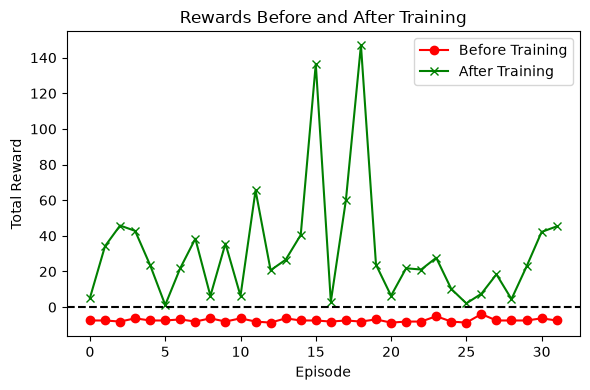

In [22]:
import matplotlib.pyplot as plt
# رسم المكافآت قبل وبعد التدريب
plt.figure(figsize=(6, 4))
# مكافآت الأفعال العشوائية
plt.plot(reward_history_before, label='Before Training', color='red', linestyle='-', marker='o')
# مكافآت أفعال النموذج المدرب
plt.plot(reward_history_after, label='After Training', color='green', linestyle='-', marker='x')

# تخصيص النموذج
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rewards Before and After Training")
# رسم المحور الأفقي
plt.axhline(y=0, color='black', linestyle='--')
plt.legend()

# العرض
plt.tight_layout()
plt.show()

In [26]:
# الاستيراد الصحيح للإصدارات الحديثة
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip

# أو يمكنك استيراد الكائن مباشرة
import moviepy as mp
# ثم استخدامه هكذا: mp.ImageSequenceClip(...)

In [27]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [28]:
# مسار مجلد الأفلام
clips_folder='./'

In [29]:
n_eval_episodes=10
for episode in range(n_eval_episodes):
    # قائمة لحفظ الصور المتتالية
    frames = []
    # مؤشر الانتهاء
    done = False
    # إجمالي مكافآت الحلقة الواحدة
    total_reward = 0
    # إعادة التهيئة
    obs, info = env.reset()
    # إضافة صورة البيئة
    frames.append(env.render())
    while not done:
        # فعل من النموذج
        action, info = model.predict(obs)
        # تنفيذ الفعل
        obs, reward, terminated, truncated, info = env.step(action)
        # إضافة صورة البيئة
        frames.append(env.render())
        # إضافة المكافأة الحالية لإجمالي المكافآت
        total_reward = total_reward + reward
        if terminated or truncated:
          done=True
    # إنشاء فلم من قائمة الصور
    clip = ImageSequenceClip(frames, fps=10)
    # اسم الملف
    clip_file_name=f'trained_flappybird_episodes_{total_timesteps}_{total_reward}.mp4'
    # مسار الملف
    clip_file_name_path= clips_folder+clip_file_name
    # حفظ الملف
    clip.write_videofile(clip_file_name_path)

MoviePy - Building video ./trained_flappybird_episodes_100000_73.69999999999987.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_73.69999999999987.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_73.69999999999987.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_56.00000000000064.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_56.00000000000064.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_56.00000000000064.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_43.70000000000048.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_43.70000000000048.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_43.70000000000048.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_55.50000000000064.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_55.50000000000064.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_55.50000000000064.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_-3.400000000000001.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_-3.400000000000001.mp4



...

MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_40.30000000000039.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_36.70000000000036.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_36.70000000000036.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_36.70000000000036.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_6.999999999999982.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_6.999999999999982.mp4



MoviePy - Done !
MoviePy - video ready ./trained_flappybird_episodes_100000_6.999999999999982.mp4
MoviePy - Building video ./trained_flappybird_episodes_100000_4.799999999999997.mp4.
MoviePy - Writing video ./trained_flappybird_episodes_100000_4.799999999999997.mp4



MoviePy - Done !


MoviePy - video ready ./trained_flappybird_episodes_100000_4.799999999999997.mp4


In [30]:
# إغلاق البيئة
env.close()